In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib as mpl
from matplotlib.lines import Line2D

# ----------------------------
# CONFIG
# ----------------------------
path = Path("input_data/aircraft.xlsx")
out_dir = Path("figures_aircraft_tires")
out_dir.mkdir(parents=True, exist_ok=True)

SAVE_FIGS = True
SHOW_FIGS = True
ONLY_PROFILE_CLASSES = True  # keep only Est_NRibs in {3,5,7}

# Global styling (matplotlib defaults, tuned for papers)
mpl.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.axisbelow": True,
})

# One consistent palette for everything
CMAP_NAME = "viridis"
cmap_cls = mpl.cm.get_cmap(CMAP_NAME)

def _save_show(fig, fname_base):
    if SAVE_FIGS:
        fig.savefig(out_dir / f"{fname_base}.png", bbox_inches="tight")
        #fig.savefig(out_dir / f"{fname_base}.pdf", bbox_inches="tight")
    if SHOW_FIGS:
        plt.show()
    else:
        plt.close(fig)

def _beautify_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.22)
    return ax

def pick_col(df, candidates):
    return next((c for c in candidates if c in df.columns), None)

def coerce_numeric(df, cols):
    for c in cols:
        if c and c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def clean_for_plot(df, cols, ribs_col):
    keep = [c for c in cols if c is not None and c in df.columns]
    d = df[keep + [ribs_col]].copy()
    for c in keep:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d[ribs_col] = pd.to_numeric(d[ribs_col], errors="coerce")
    d = d.dropna()
    return d, keep

def legend_from_scatter(ax, sc, class_order, class_to_code, title="Est_NRibs", **kwargs):
    handles = []
    cmap = sc.get_cmap()
    norm = sc.norm
    for c in class_order:
        code = class_to_code[c]
        handles.append(
            Line2D(
                [0], [0],
                marker="o", linestyle="",
                markerfacecolor=cmap(norm(code)),
                markeredgecolor="k",
                markersize=7,
                label=str(c),
            )
        )
    leg = ax.legend(handles=handles, title=title, **kwargs)
    return leg

C:\Users\johannc2\AppData\Local\Temp\ipykernel_14100\3865630632.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cls = mpl.cm.get_cmap(CMAP_NAME)


Loaded sheet: Aircraft rows: 413 cols: 26


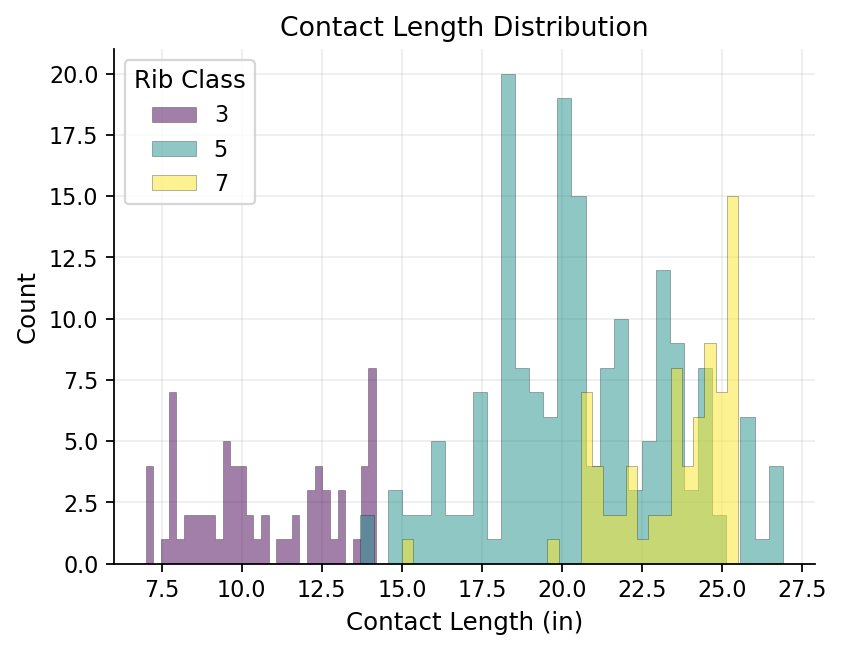

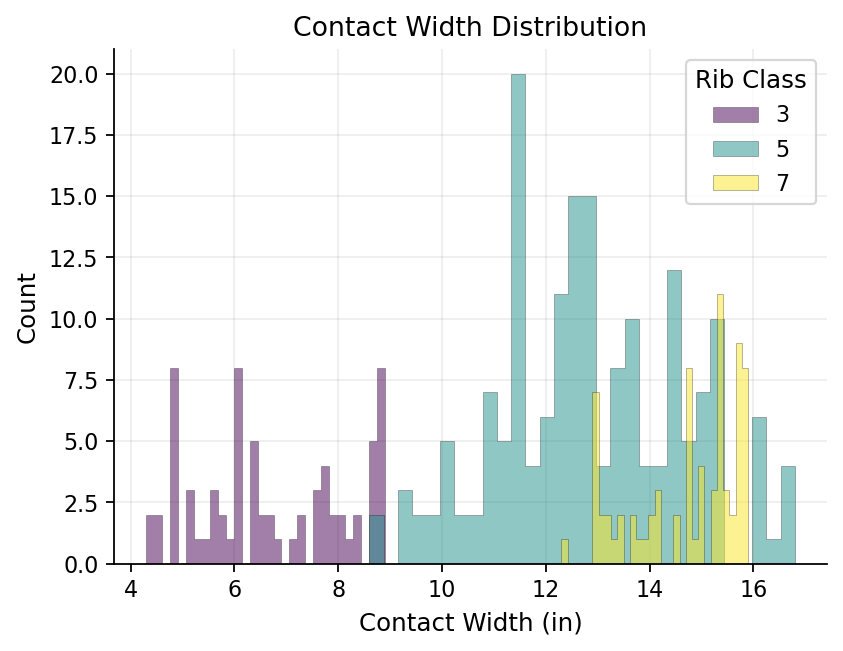

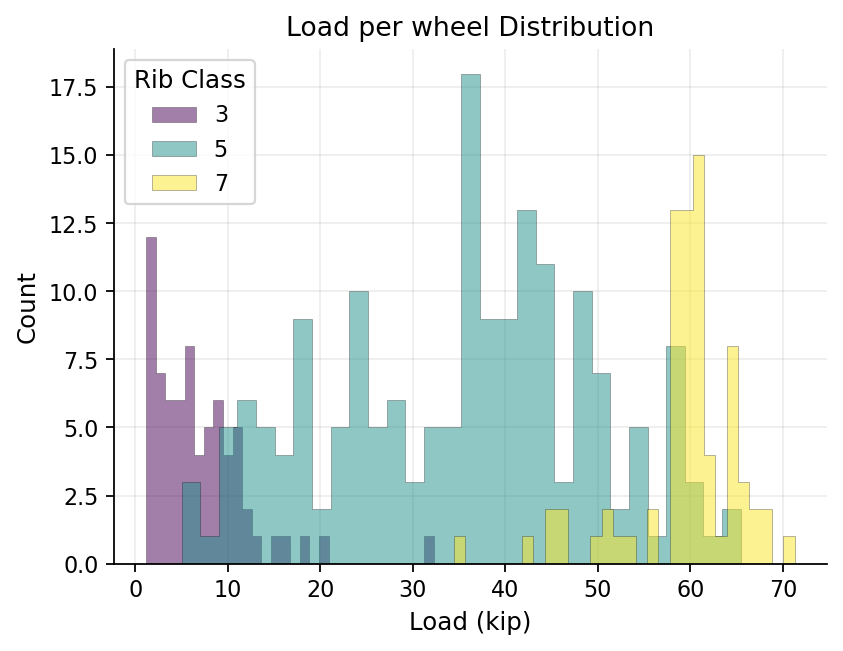

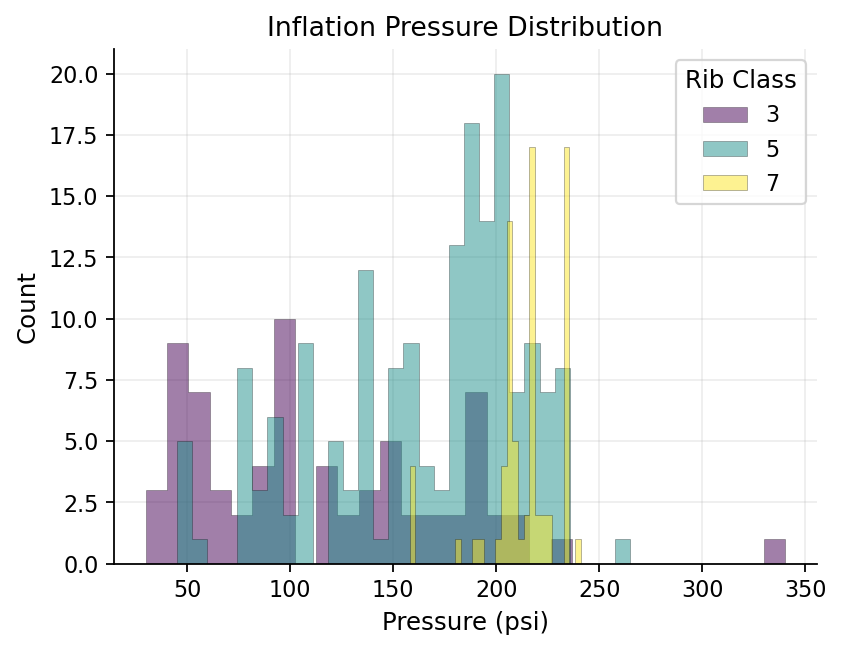

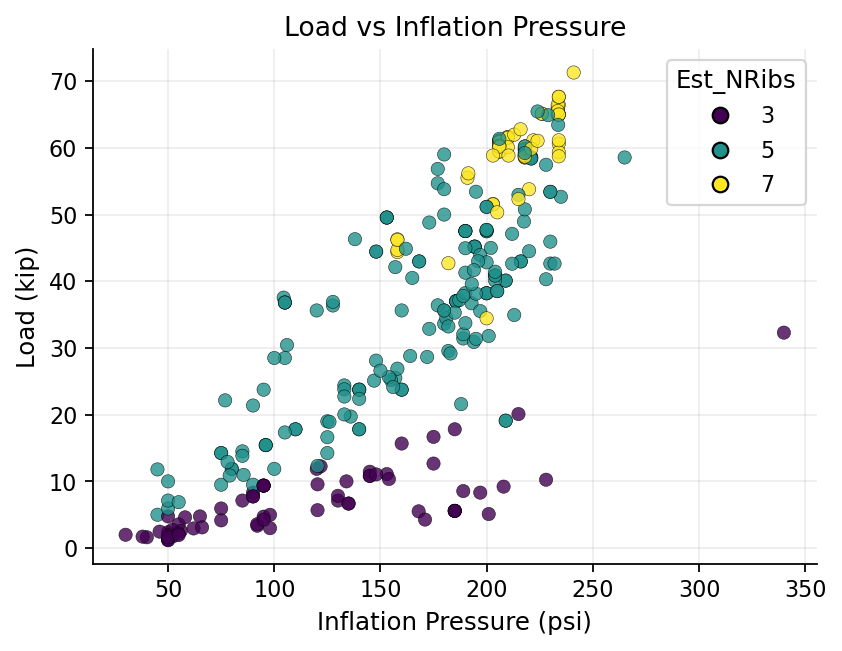

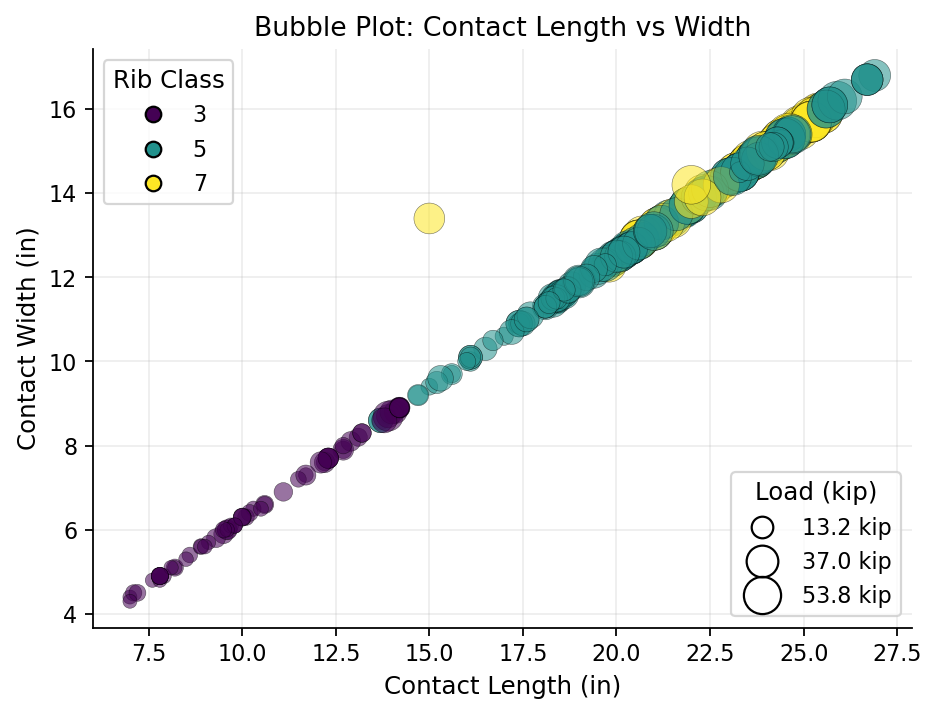

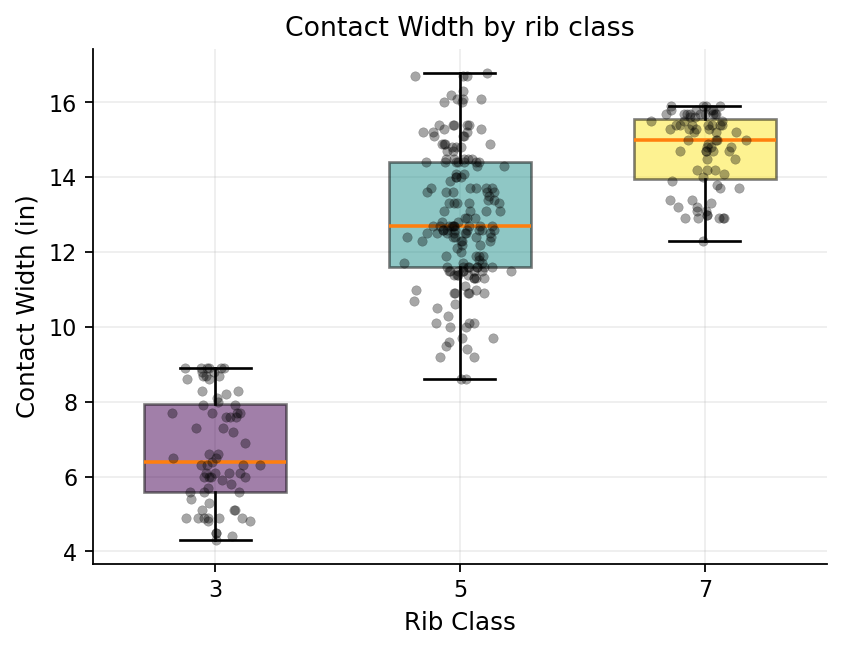

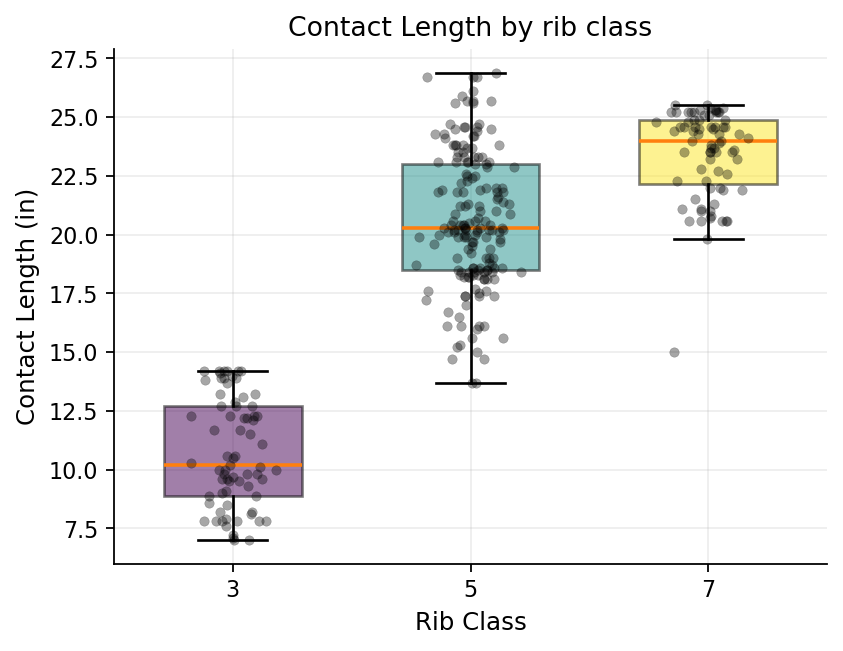

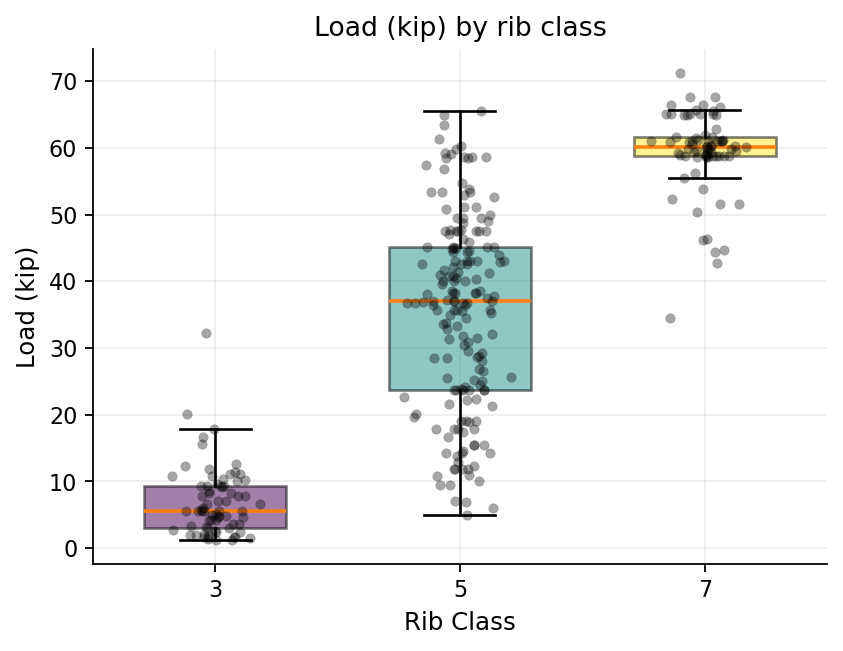

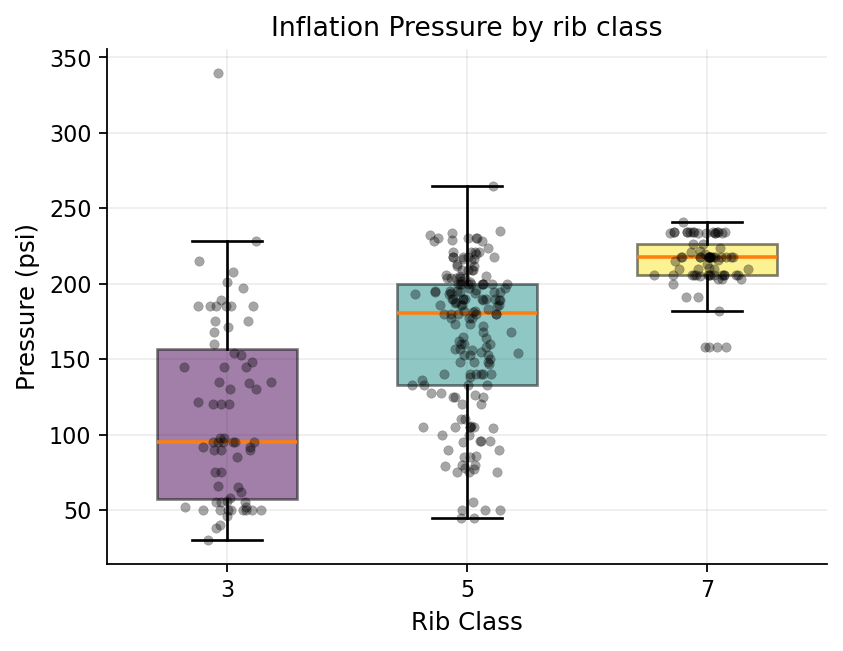

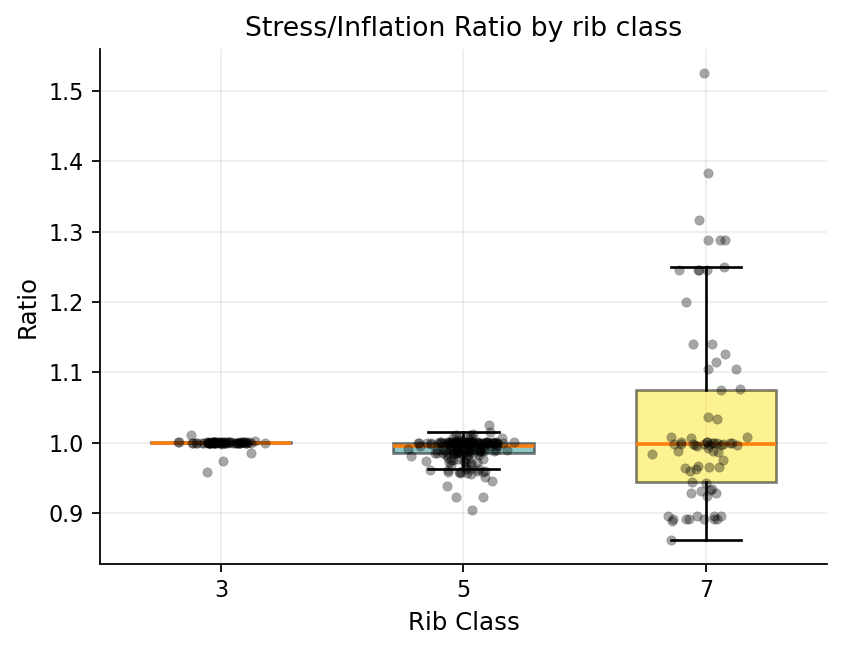


=== Logistic regression (multinomial) quick check ===
CV accuracy mean ± std: 0.9160 ± 0.0470
                              feature  coef_abs_mean
                           Load (kip)       1.176723
             Tire Contact Width (in.)       1.002686
            Tire Contact Length (in.)       0.999511
            Tire Contact Area (in.^2)       0.851147
                 Load/Pressure (in^2)       0.843181
                   Aspect Ratio (L/W)       0.480243
               Stress/Inflation Ratio       0.439486
                  Tire Pressure (psi)       0.429269
Mean Contact Stress (psi) = Load/Area       0.236975
          Rectangularity = Area/(L*W)       0.144940


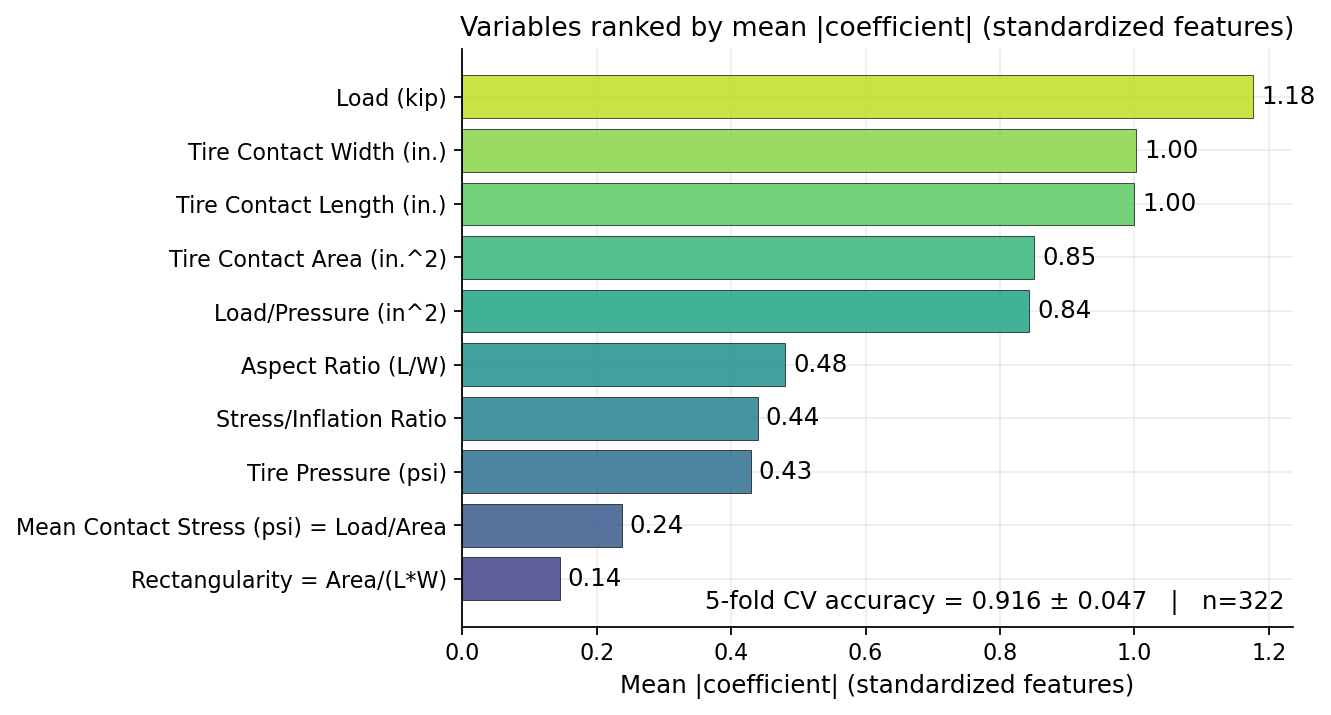


Done. Figures saved to: C:\Users\johannc2\Box\05 Repositories\ACRP-Lab\figures_aircraft_tires


In [32]:
# ----------------------------
# LOAD DATA
# ----------------------------
if not path.exists():
    raise FileNotFoundError("File not found at input_data/aircraft.xlsx")

xls = pd.ExcelFile(path)
sheet = "Aircraft" if "Aircraft" in xls.sheet_names else xls.sheet_names[0]
df = pd.read_excel(path, sheet_name=sheet)
print("Loaded sheet:", sheet, "rows:", len(df), "cols:", len(df.columns))

# ----------------------------
# COLUMN DETECTION
# ----------------------------
col_len = pick_col(df, ["Tire Contact Length (in.)", "Tire Contact Length (in,)", "Contact Length (in)", "Contact Length (in.)"])
col_wid = pick_col(df, ["Tire Contact Width (in.)", "Contact Width (in)", "Contact Width (in.)"])
col_area = pick_col(df, ["Tire Contact Area (in.^2)", "Tire Contact Area (in.2)", "Tire Contact Area (in^2)", "Tire Contact Area (in.^2)"])
col_load_lbs = pick_col(df, ["Load (lbs)", "Load_perWheel_lbs", "Load per Wheel (lbs)", "Load per Tire (lbs)"])
col_press = pick_col(df, ["Tire Pressure (psi)", "Pressure (psi)", "Inflation Pressure (psi)"])
col_ribs = pick_col(df, ["Est_NRibs", "Likely_NRibs", "NRibs", "Ribs"])

if col_len is None:
    raise ValueError("No Contact Length column found (needed for filtering + key plots).")
if col_ribs is None:
    raise ValueError("Need Est_NRibs (or similar) column to color/stratify plots.")

# ----------------------------
# BASIC CLEANING
# ----------------------------
df = coerce_numeric(df, [col_len, col_wid, col_area, col_load_lbs, col_press, col_ribs])
df = df[df[col_len].notna() & (df[col_len] > 0)].copy()
df[col_ribs] = pd.to_numeric(df[col_ribs], errors="coerce").fillna(5).astype(int)

if ONLY_PROFILE_CLASSES:
    df = df[df[col_ribs].isin([3, 5, 7])].copy()

# ----------------------------
# DERIVED VARIABLES
# ----------------------------
df["Load (kip)"] = (df[col_load_lbs] / 1000.0) if col_load_lbs else np.nan

if col_len and col_wid:
    df["Aspect Ratio (L/W)"] = df[col_len] / df[col_wid]

if col_area and col_len and col_wid:
    df["Rectangularity = Area/(L*W)"] = df[col_area] / (df[col_len] * df[col_wid])

if col_area and col_load_lbs:
    df["Mean Contact Stress (psi) = Load/Area"] = df[col_load_lbs] / df[col_area]
    if col_press:
        df["Stress/Inflation Ratio"] = df["Mean Contact Stress (psi) = Load/Area"] / df[col_press]

if col_press and col_load_lbs:
    df["Load/Pressure (in^2)"] = df[col_load_lbs] / df[col_press]

# ----------------------------
# COLOR HANDLING (DISCRETE classes, viridis-consistent everywhere)
# ----------------------------
class_order = sorted(df[col_ribs].unique().tolist())
class_to_code = {c: i for i, c in enumerate(class_order)}
norm_cls = mpl.colors.Normalize(vmin=min(class_to_code.values()), vmax=max(class_to_code.values()))
class_to_color = {c: cmap_cls(norm_cls(class_to_code[c])) for c in class_order}

# ----------------------------
# PLOTS
# ----------------------------

# 1) Hist overlays (viridis per class)
def hist_by_class(col, title, xlabel, bins=30, fname="hist"):
    if col is None or col not in df.columns:
        return
    fig, ax = plt.subplots(figsize=(5.4, 4.2))
    for cls in class_order:
        s = pd.to_numeric(df.loc[df[col_ribs] == cls, col], errors="coerce").dropna()
        if len(s) == 0:
            continue
        ax.hist(
            s, bins=bins,
            alpha=0.50,
            color=class_to_color[cls],
            edgecolor="k", linewidth=0.25,
            label=f"{cls}",
            histtype="stepfilled"
        )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.legend(title="Rib Class", frameon=True, fancybox=True)
    _beautify_ax(ax)
    fig.tight_layout()
    _save_show(fig, fname)

hist_by_class(col_len,      "Contact Length Distribution",      "Contact Length (in)",      fname="hist_contact_length_by_ribs")
hist_by_class(col_wid,      "Contact Width Distribution",       "Contact Width (in)",       fname="hist_contact_width_by_ribs")
hist_by_class("Load (kip)", "Load per wheel Distribution",      "Load (kip)",               fname="hist_load_by_ribs")
hist_by_class(col_press,    "Inflation Pressure Distribution",  "Pressure (psi)",           fname="hist_pressure_by_ribs")

# 2) Scatter: Load vs Pressure (colored by ribs)
if col_press and "Load (kip)" in df.columns:
    d, _ = clean_for_plot(df, [col_press, "Load (kip)"], col_ribs)
    fig, ax = plt.subplots(figsize=(5.4, 4.2))
    sc = ax.scatter(
        d[col_press], d["Load (kip)"],
        c=d[col_ribs].map(class_to_code),
        s=36, alpha=0.80,
        cmap=cmap_cls, norm=norm_cls,
        edgecolors="k", linewidths=0.25
    )
    ax.set_title("Load vs Inflation Pressure")
    ax.set_xlabel("Inflation Pressure (psi)")
    ax.set_ylabel("Load (kip)")
    _beautify_ax(ax)
    legend_from_scatter(ax, sc, class_order, class_to_code, loc="best", frameon=True, fancybox=True)
    fig.tight_layout()
    _save_show(fig, "scatter_load_vs_pressure_by_ribs")

# 3) Bubble: X=Length, Y=Width, size=Load, color=Est_NRibs (two legends, both kept)
if col_len and col_wid and "Load (kip)" in df.columns:
    d, _ = clean_for_plot(df, [col_len, col_wid, "Load (kip)"], col_ribs)

    s = d["Load (kip)"].to_numpy(float)
    s_scaled = 40 + 320 * (s - np.nanmin(s)) / (np.nanmax(s) - np.nanmin(s) + 1e-12)

    fig, ax = plt.subplots(figsize=(6.0, 4.6))
    sc = ax.scatter(
        d[col_len], d[col_wid],
        s=s_scaled,
        c=d[col_ribs].map(class_to_code),
        alpha=0.55,
        cmap=cmap_cls, norm=norm_cls,
        edgecolors="k", linewidths=0.25
    )

    ax.set_title("Bubble Plot: Contact Length vs Width")
    ax.set_xlabel("Contact Length (in)")
    ax.set_ylabel("Contact Width (in)")
    _beautify_ax(ax)

    # Legend 1: rib class colors
    leg1 = legend_from_scatter(
        ax, sc, class_order, class_to_code,
        title="Rib Class",
        loc="upper left",
        frameon=True, fancybox=True
    )
    ax.add_artist(leg1)  # <- keeps leg1 when leg2 is added

    # Legend 2: bubble size key (Load)
    refs = np.unique(np.round(np.quantile(d["Load (kip)"], [0.25, 0.5, 0.75]), 2))
    size_handles = []
    for ref in refs:
        ref_s = 40 + 320 * (ref - np.nanmin(s)) / (np.nanmax(s) - np.nanmin(s) + 1e-12)
        size_handles.append(
            Line2D(
                [0], [0],
                marker="o", linestyle="",
                markerfacecolor="none",
                markeredgecolor="k",
                markersize=np.sqrt(ref_s),
                label=f"{ref:.1f} kip"
            )
        )
    ax.legend(handles=size_handles, title="Load (kip)", loc="lower right", frameon=True, fancybox=True)

    fig.tight_layout()
    _save_show(fig, "bubble_length_width_load_ribs")

# 4) Boxplots with viridis-colored boxes + jitter scatter (warning-free tick_labels)
def box_by_ribs(col, title, ylabel, fname,
                box_alpha=0.50, point_alpha=0.35,
                jitter=0.08, point_size=18, seed=123):
    if col is None or col not in df.columns:
        return
    d = df[[col_ribs, col]].dropna()
    if len(d) == 0:
        return

    d[col_ribs] = pd.to_numeric(d[col_ribs], errors="coerce")
    d = d.dropna(subset=[col_ribs])
    d[col_ribs] = d[col_ribs].astype(int)

    classes = sorted(d[col_ribs].unique())
    groups = [d.loc[d[col_ribs] == k, col].to_numpy(dtype=float) for k in classes]
    labels = [str(k) for k in classes]

    fig, ax = plt.subplots(figsize=(5.4, 4.2))
    bp = ax.boxplot(
        groups,
        tick_labels=labels,
        showfliers=False,
        patch_artist=True,
        widths=0.58,
        medianprops=dict(linewidth=1.6),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )

    # Viridis-consistent coloring per rib class
    for i, k in enumerate(classes):
        c = class_to_color.get(k, (0.5, 0.5, 0.5, 1.0))
        bp["boxes"][i].set_facecolor(c)
        bp["boxes"][i].set_alpha(box_alpha)
        bp["boxes"][i].set_edgecolor("k")

    rng = np.random.default_rng(seed)
    for i, y in enumerate(groups, start=1):
        if len(y) == 0:
            continue
        x = i + rng.normal(0.0, jitter, size=len(y))
        ax.scatter(
            x, y,
            s=point_size, alpha=point_alpha, color="black",
            linewidths=0.2, edgecolors="k", zorder=3
        )

    ax.set_title(title)
    ax.set_xlabel("Rib Class")
    ax.set_ylabel(ylabel)
    _beautify_ax(ax)
    fig.tight_layout()
    _save_show(fig, fname)

box_by_ribs(col_wid,   "Contact Width by rib class",          "Contact Width (in)", "box_width_by_ribs")
box_by_ribs(col_len,   "Contact Length by rib class",         "Contact Length (in)", "box_length_by_ribs")
box_by_ribs("Load (kip)", "Load (kip) by rib class",          "Load (kip)", "box_load_by_ribs")
box_by_ribs(col_press, "Inflation Pressure by rib class",     "Pressure (psi)", "box_pressure_by_ribs")
box_by_ribs("Stress/Inflation Ratio", "Stress/Inflation Ratio by rib class", "Ratio", "box_stress_infl_ratio_by_ribs")

# 5) Feature-importance plot (refined, viridis + alpha, no sklearn FutureWarning)
try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import StratifiedKFold, cross_val_score

    feat_cols = [c for c in [
        col_len, col_wid, col_area, "Load (kip)", col_press,
        "Aspect Ratio (L/W)",
        "Rectangularity = Area/(L*W)",
        "Mean Contact Stress (psi) = Load/Area",
        "Stress/Inflation Ratio",
        "Load/Pressure (in^2)"
    ] if c in df.columns and c is not None]

    d = df[feat_cols + [col_ribs]].copy()
    d = d.apply(pd.to_numeric, errors="coerce").dropna()
    d = d[d[col_ribs].isin([3, 5, 7])]

    if len(d) >= 30 and len(d[col_ribs].unique()) >= 2:
        X = d[feat_cols].to_numpy(float)
        y = d[col_ribs].to_numpy(int)

        # Standardize
        mu = X.mean(axis=0)
        sd = X.std(axis=0) + 1e-12
        Xz = (X - mu) / sd

        clf = LogisticRegression(max_iter=800, solver="lbfgs")  # no multi_class arg => no warning
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        acc = cross_val_score(clf, Xz, y, cv=cv, scoring="accuracy")
        clf.fit(Xz, y)

        coef_mag = np.mean(np.abs(clf.coef_), axis=0)
        imp = (pd.DataFrame({"feature": feat_cols, "coef_abs_mean": coef_mag})
                 .sort_values("coef_abs_mean", ascending=False))

        print("\n=== Logistic regression (multinomial) quick check ===")
        print(f"CV accuracy mean ± std: {acc.mean():.4f} ± {acc.std():.4f}")
        print(imp.head(12).to_string(index=False))

        top = imp.head(10).iloc[::-1]
        vals = top["coef_abs_mean"].to_numpy()

        fig, ax = plt.subplots(figsize=(8.4, 4.6))

        # viridis gradient + alpha
        colors = cmap_cls(np.linspace(0.20, 0.90, len(top)))
        bars = ax.barh(
            top["feature"], vals,
            color=colors, alpha=0.85,
            edgecolor="k", linewidth=0.35
        )

        # value labels
        x_pad = 0.01 * (vals.max() + 1e-9)
        for b, v in zip(bars, vals):
            ax.text(
                b.get_width() + x_pad,
                b.get_y() + b.get_height()/2,
                f"{v:.2f}",
                va="center", ha="left"
            )

        ax.set_title("Variables ranked by mean |coefficient| (standardized features)")
        ax.set_xlabel("Mean |coefficient| (standardized features)")
        ax.text(
            0.99, 0.02,
            f"5-fold CV accuracy = {acc.mean():.3f} ± {acc.std():.3f}   |   n={len(d)}",
            transform=ax.transAxes, ha="right", va="bottom"
        )

        _beautify_ax(ax)
        fig.tight_layout()
        _save_show(fig, "feature_importance_logit_refined")

except Exception as e:
    print("Model-based importance skipped (scikit-learn missing or error):", e)

print(f"\nDone. Figures saved to: {out_dir.resolve() if SAVE_FIGS else '(saving disabled)'}")